# Exploratory Data Analysis (EDA)

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (8,5)

In [36]:
df = pd.read_parquet('../Data/traffic_cleaned.parquet')

In [37]:
df = df.sort_values('date_time').reset_index(drop=True)

In [38]:
df[['date_time', 'traffic_volume']].head()

,date_time,traffic_volume
0,2012-10-02 09:00:00,5545.0
1,2012-10-02 10:00:00,4516.0
2,2012-10-02 12:00:00,5026.0
3,2012-10-02 13:00:00,4918.0
4,2012-10-02 14:00:00,5181.0


# Univariate Analysis

In [39]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns.to_list()

print("Numerical Columns:", num_cols)

Numerical Columns: ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'fog_mm', 'wind_speed_ms', 'flood_mm', 'traffic_volume']


In [40]:
cat_cols = df.select_dtypes(include="object").columns.to_list()

print("Categorical Columns:", cat_cols)

Categorical Columns: ['holiday', 'weather_main', 'weather_description', 'day_type']


In [41]:
def univ_num_explore(data, num_col, figsize=(10, 4)):
    """
    Analyze a numerical column:
    - Summary statistics
    - Histogram + KDE
    - Boxplot
    """

    print(f"Analysis for '{num_col}'")
    print("*" * 50)

    # Summary Statistics
    print(data[num_col].describe())

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Histogram + KDE
    sns.histplot(
        data=data,
        x=num_col,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(
        f"Distribution of {num_col}"
    )

    # Boxplot
    sns.boxplot(
        data=data,
        x=num_col,
        ax=axes[1]
    )

    axes[1].set_title(
        f"Boxplot of {num_col}"
    )

    plt.tight_layout()
    plt.show()

In [42]:
continuous_cols = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'fog_mm',
    'wind_speed_ms',
    'flood_mm',
    'traffic_volume'
]

Analysis for 'temp'
**************************************************
count    45794.000000
mean       281.321778
std         12.393036
min        243.390000
25%        272.610000
50%        282.429000
75%        291.480000
max        310.070000
Name: temp, dtype: float64


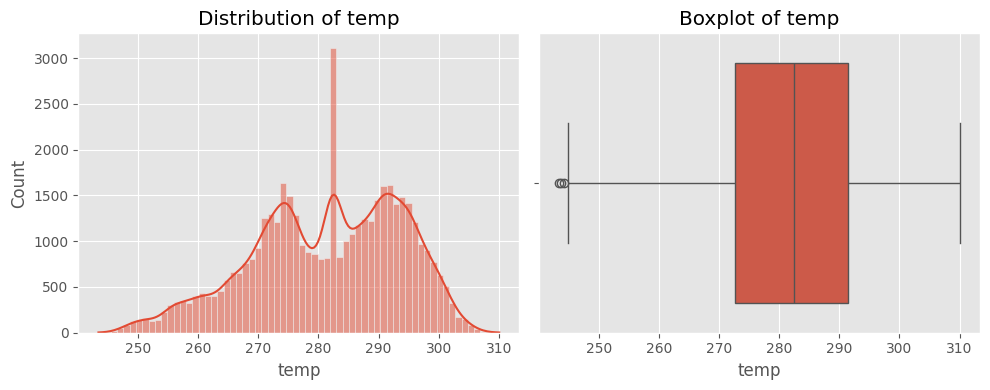

Analysis for 'rain_1h'
**************************************************
count    45794.000000
mean         0.339396
std         45.951680
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       9831.300000
Name: rain_1h, dtype: float64


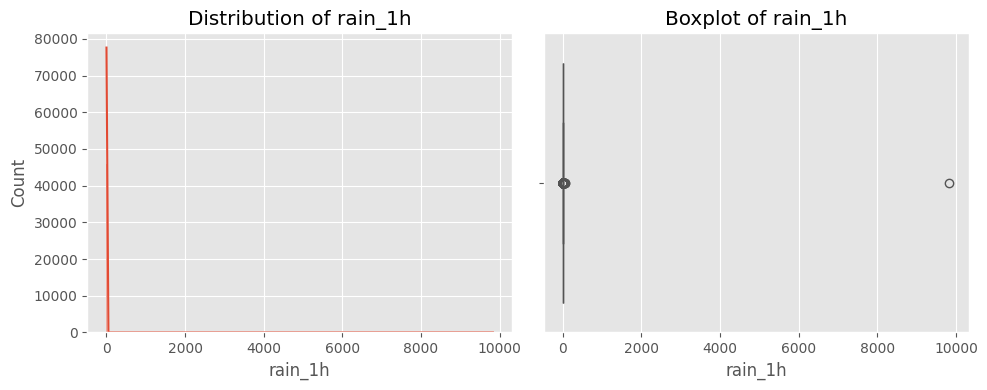

Analysis for 'snow_1h'
**************************************************
count    45794.000000
mean         0.000217
std          0.008101
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.510000
Name: snow_1h, dtype: float64


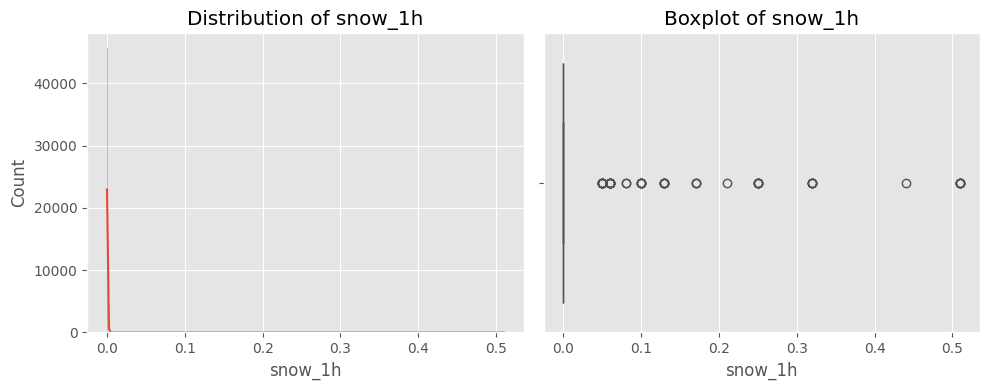

Analysis for 'clouds_all'
**************************************************
count    45794.000000
mean        50.143643
std         38.188424
min          0.000000
25%          1.000000
50%         64.000000
75%         90.000000
max        100.000000
Name: clouds_all, dtype: float64


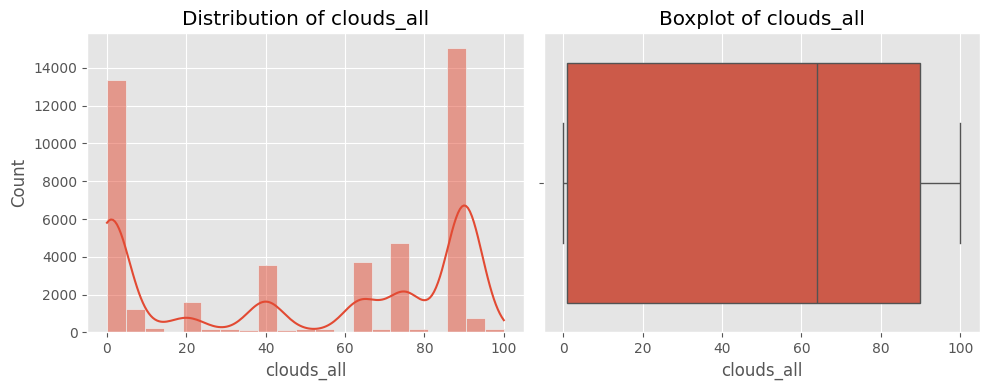

Analysis for 'fog_mm'
**************************************************
count    45794.000000
mean         8.586052
std         42.219038
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        499.260000
Name: fog_mm, dtype: float64


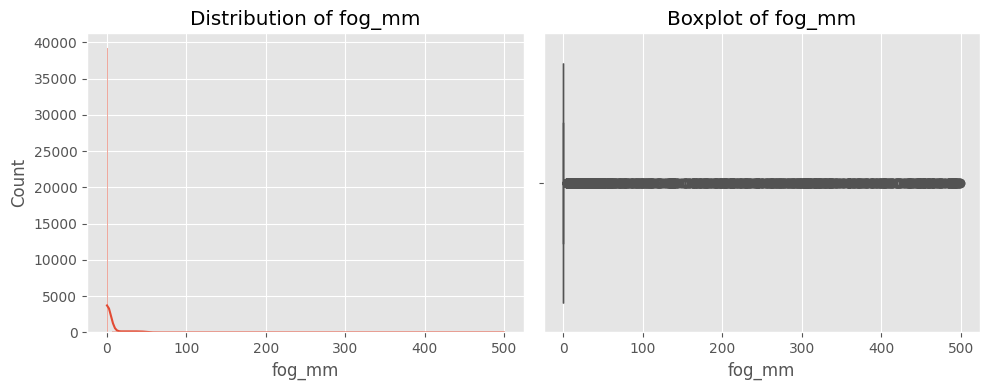

Analysis for 'wind_speed_ms'
**************************************************
count    45794.000000
mean         5.399888
std          3.549181
min          0.500000
25%          2.830000
50%          5.050000
75%          7.050000
max         24.980000
Name: wind_speed_ms, dtype: float64


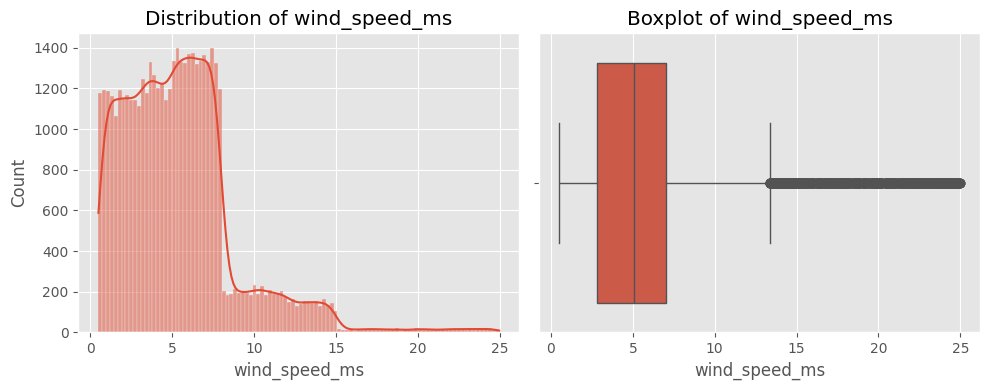

Analysis for 'flood_mm'
**************************************************
count    45794.000000
mean         0.787963
std          8.193217
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        407.930000
Name: flood_mm, dtype: float64


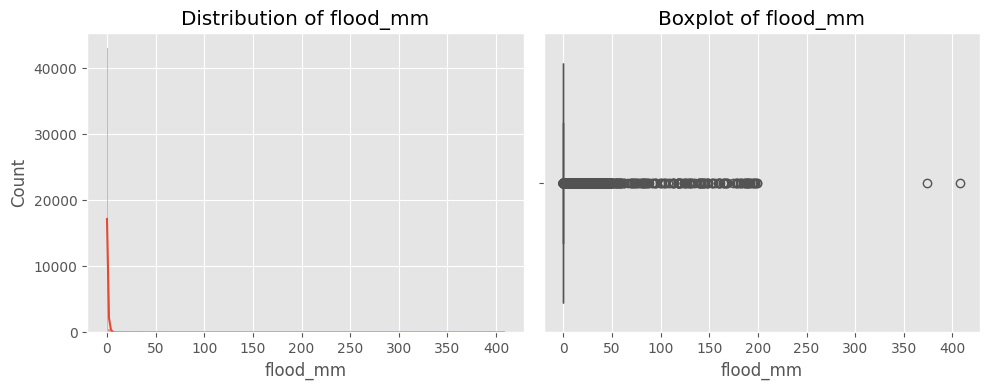

Analysis for 'traffic_volume'
**************************************************
count    45794.000000
mean      3261.366991
std       1987.139170
min          0.000000
25%       1195.000000
50%       3380.000000
75%       4936.000000
max       7280.000000
Name: traffic_volume, dtype: float64


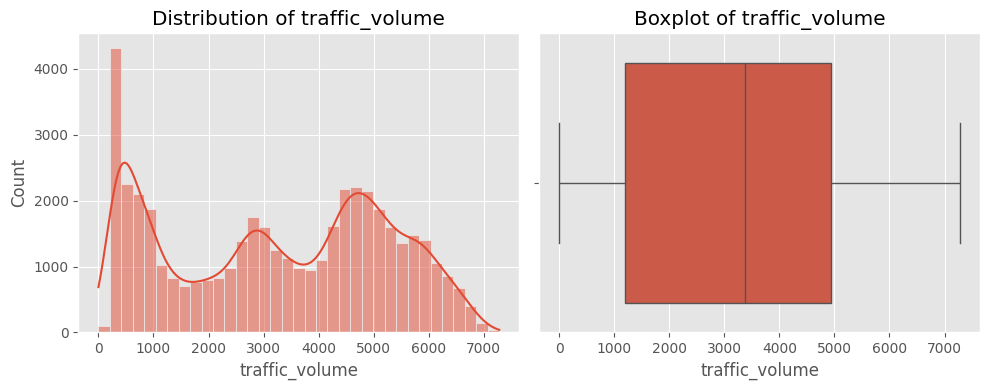

In [43]:
for num_col in continuous_cols:
    univ_num_explore(df, num_col)

In [47]:
def univ_cat_explore(data, cat_col, top_n=10, figsize=(8,5)):
    """
    Analyze a categorical column:
    - Value counts
    - Percentage
    - Pie chart (if <=4 categories)
    - Count plot (otherwise)
    """

    print(f"Analysis for '{cat_col}'")
    print("*" * 50)

    # Count
    counts = data[cat_col].value_counts()

    print("Value Counts:")
    print(counts)

    # Percentage
    print("\nPercentage:")
    percentages = (
        data[cat_col]
        .value_counts(normalize=True) * 100
    ).round(2)

    print(percentages)

    # Top Categories
    top_categories = counts.head(top_n)

    # Pie Chart
    if data[cat_col].nunique() <= 4:

        plt.figure(figsize=figsize)

        counts.plot(
            kind='pie',
            autopct='%1.1f%%'
        )

        plt.ylabel("")
        plt.title(f"Distribution of {cat_col}")

        plt.show()

    # Count Plot
    else:

        plt.figure(figsize=figsize)

        sns.countplot(
            data=data,
            x=cat_col,
            order=top_categories.index
        )

        plt.title(
            f"Top {top_n} Categories in {cat_col}"
        )

        plt.xticks(rotation=45)

        plt.tight_layout()

        plt.show()

Analysis for 'holiday'
**************************************************
Value Counts:
holiday
No Holiday                   45736
Labor Day                        7
Christmas Day                    6
Thanksgiving Day                 6
New Years Day                    6
Veterans Day                     5
Independence Day                 5
Memorial Day                     5
Martin Luther King Jr Day        5
State Fair                       5
Washingtons Birthday             4
Columbus Day                     4
Name: count, dtype: int64

Percentage:
holiday
No Holiday                   99.87
Labor Day                     0.02
Christmas Day                 0.01
Thanksgiving Day              0.01
New Years Day                 0.01
Veterans Day                  0.01
Independence Day              0.01
Memorial Day                  0.01
Martin Luther King Jr Day     0.01
State Fair                    0.01
Washingtons Birthday          0.01
Columbus Day                  0.01
Name: proportion,

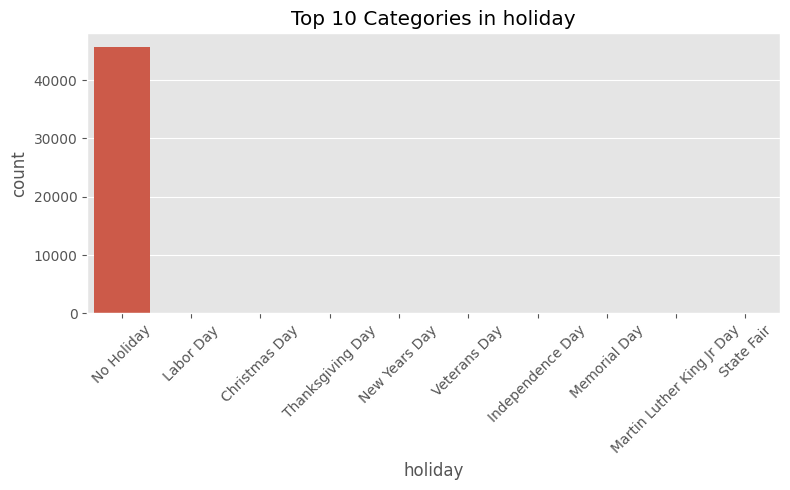

Analysis for 'weather_main'
**************************************************
Value Counts:
weather_main
Clouds          14391
Clear           12744
Mist             5647
Rain             5396
Snow             2725
Drizzle          1728
Haze             1292
Thunderstorm      979
Fog               870
Smoke              18
Squall              4
Name: count, dtype: int64

Percentage:
weather_main
Clouds          31.43
Clear           27.83
Mist            12.33
Rain            11.78
Snow             5.95
Drizzle          3.77
Haze             2.82
Thunderstorm     2.14
Fog              1.90
Smoke            0.04
Squall           0.01
Name: proportion, dtype: float64


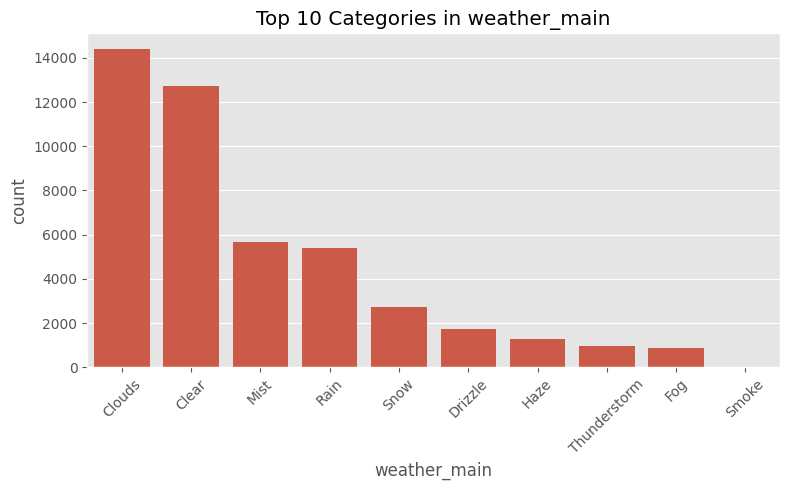

Analysis for 'weather_description'
**************************************************
Value Counts:
weather_description
sky is clear                           11102
mist                                    5647
overcast clouds                         4854
broken clouds                           4426
scattered clouds                        3268
light rain                              3213
few clouds                              1843
light snow                              1843
Sky is Clear                            1642
moderate rain                           1580
haze                                    1292
light intensity drizzle                 1043
fog                                      870
proximity thunderstorm                   635
drizzle                                  621
heavy snow                               586
heavy intensity rain                     443
snow                                     277
proximity shower rain                    128
thunderstorm             

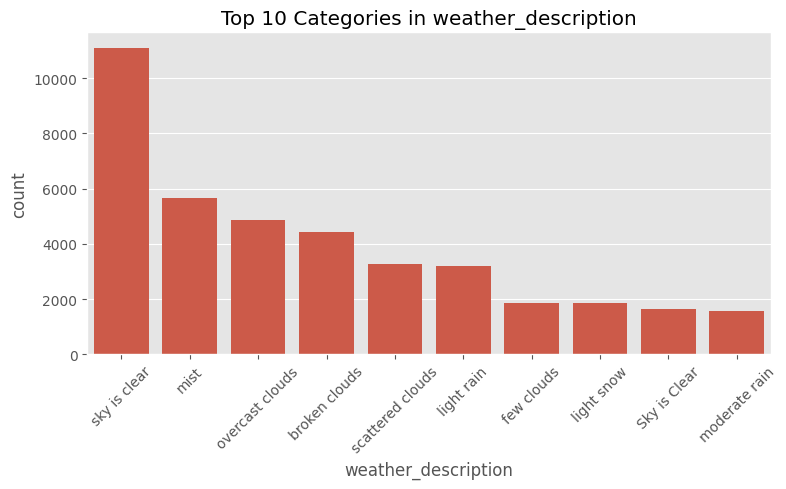

Analysis for 'day_type'
**************************************************
Value Counts:
day_type
Weekday    32777
Weekend    13017
Name: count, dtype: int64

Percentage:
day_type
Weekday    71.57
Weekend    28.43
Name: proportion, dtype: float64


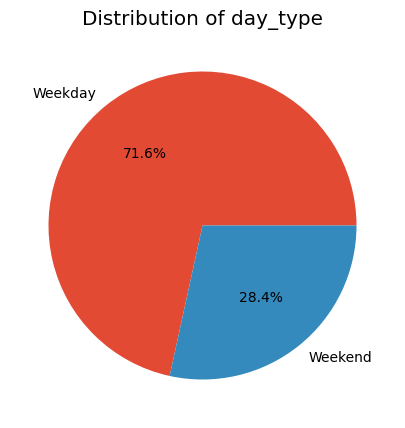

In [49]:
for cat_col in cat_cols:
    univ_cat_explore(df, cat_col)

Analysis for 'weather_main'
**************************************************
Value Counts:
weather_main
Clouds          14391
Clear           12744
Mist             5647
Rain             5396
Snow             2725
Drizzle          1728
Haze             1292
Thunderstorm      979
Fog               870
Smoke              18
Squall              4
Name: count, dtype: int64

Percentage:
weather_main
Clouds          31.43
Clear           27.83
Mist            12.33
Rain            11.78
Snow             5.95
Drizzle          3.77
Haze             2.82
Thunderstorm     2.14
Fog              1.90
Smoke            0.04
Squall           0.01
Name: proportion, dtype: float64


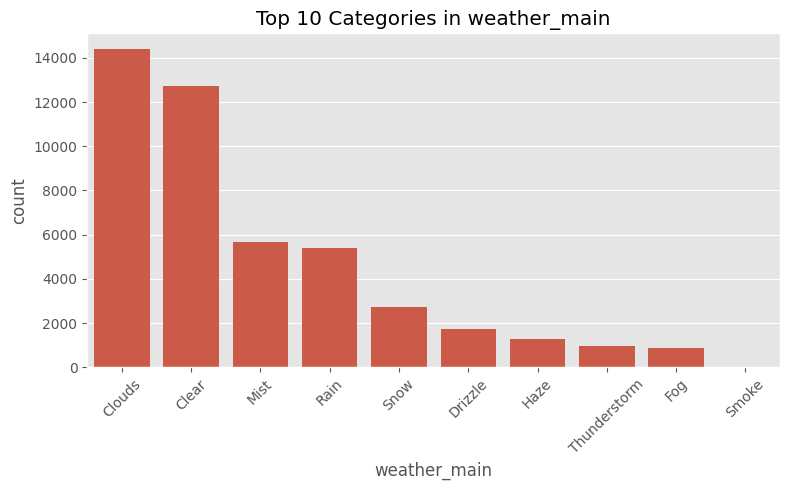

In [50]:
univ_cat_explore(df, 'weather_main')

 # Time-Based Analysis

## Step 1 — Feature Extraction

In [51]:
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year

In [52]:
df['is_weekend'] = df['day_of_week'].isin([5, 6])

In [53]:
df[['date_time', 'hour', 'day_of_week', 'month', 'year', 'is_weekend']].head()

,date_time,hour,day_of_week,month,year,is_weekend
0,2012-10-02 09:00:00,9,1,10,2012,False
1,2012-10-02 10:00:00,10,1,10,2012,False
2,2012-10-02 12:00:00,12,1,10,2012,False
3,2012-10-02 13:00:00,13,1,10,2012,False
4,2012-10-02 14:00:00,14,1,10,2012,False


## Step 2 — Traffic حسب الساعة ⏰

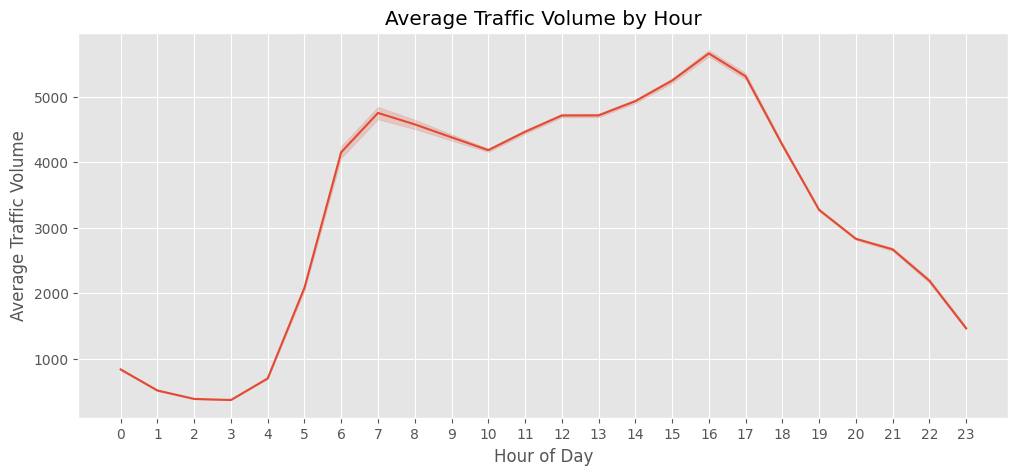

In [54]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df,
    x='hour',
    y='traffic_volume',
    estimator='mean'
)

plt.title('Average Traffic Volume by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Traffic Volume')

plt.xticks(range(24))

plt.show()

## Step 3 — Traffic حسب يوم الأسبوع 📅

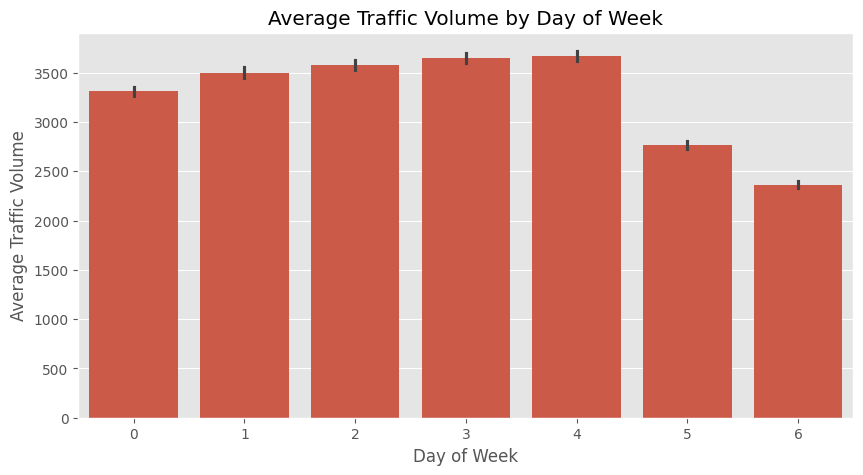

In [55]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x='day_of_week',
    y='traffic_volume',
    estimator='mean'
)

plt.title('Average Traffic Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Traffic Volume')

plt.show()

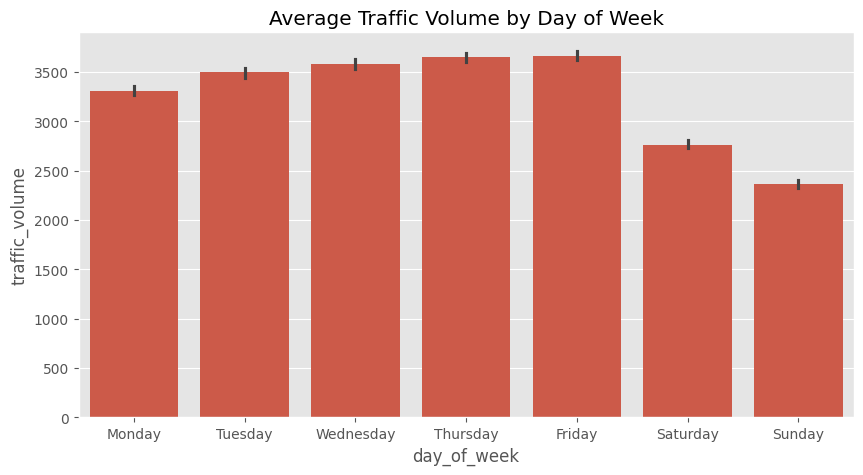

In [56]:
day_names = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x='day_of_week',
    y='traffic_volume',
    estimator='mean'
)

plt.xticks(
    ticks=range(7),
    labels=day_names
)

plt.title('Average Traffic Volume by Day of Week')

plt.show()

## Step 4 — Weekday vs Weekend

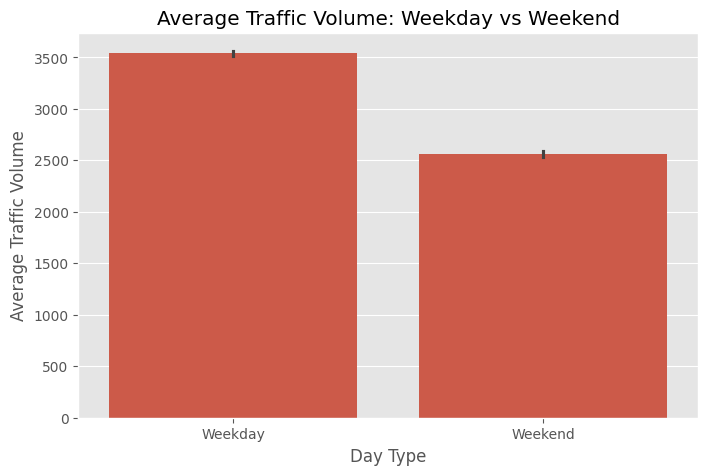

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='day_type',
    y='traffic_volume',
    estimator='mean'
)

plt.title('Average Traffic Volume: Weekday vs Weekend')

plt.xlabel('Day Type')
plt.ylabel('Average Traffic Volume')

plt.show()

## Step 5 — Traffic حسب الشهر 📊

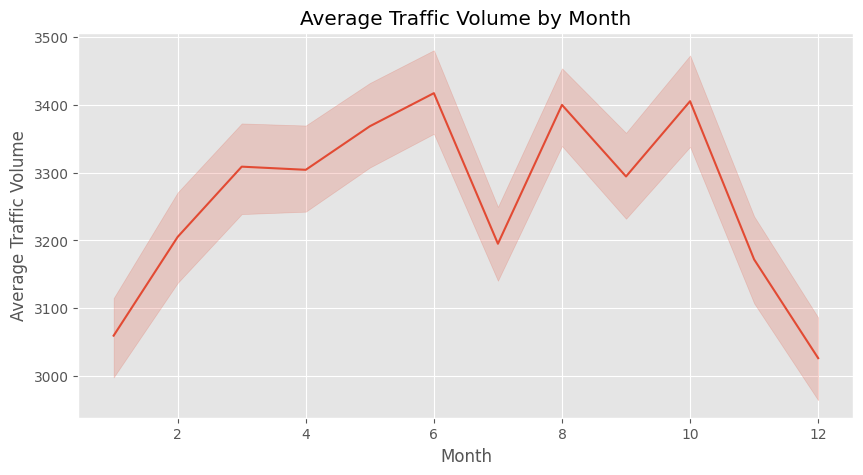

In [58]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x='month',
    y='traffic_volume',
    estimator='mean'
)

plt.title('Average Traffic Volume by Month')

plt.xlabel('Month')
plt.ylabel('Average Traffic Volume')

plt.show()

## Step 6 — Traffic حسب السنة

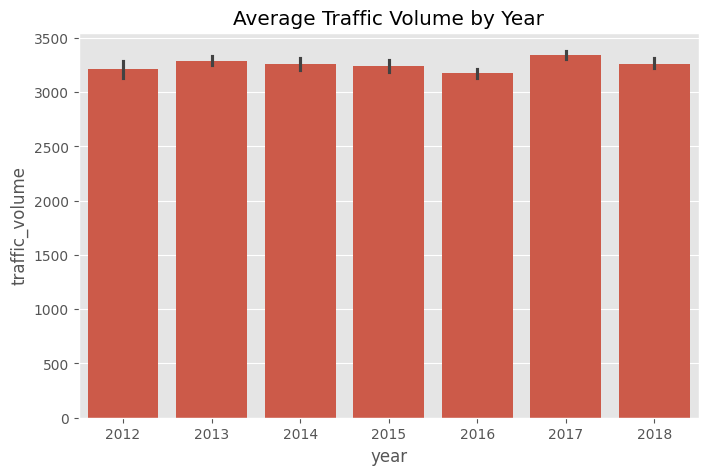

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='year',
    y='traffic_volume',
    estimator='mean'
)

plt.title('Average Traffic Volume by Year')

plt.show()

## Hour × Day Type

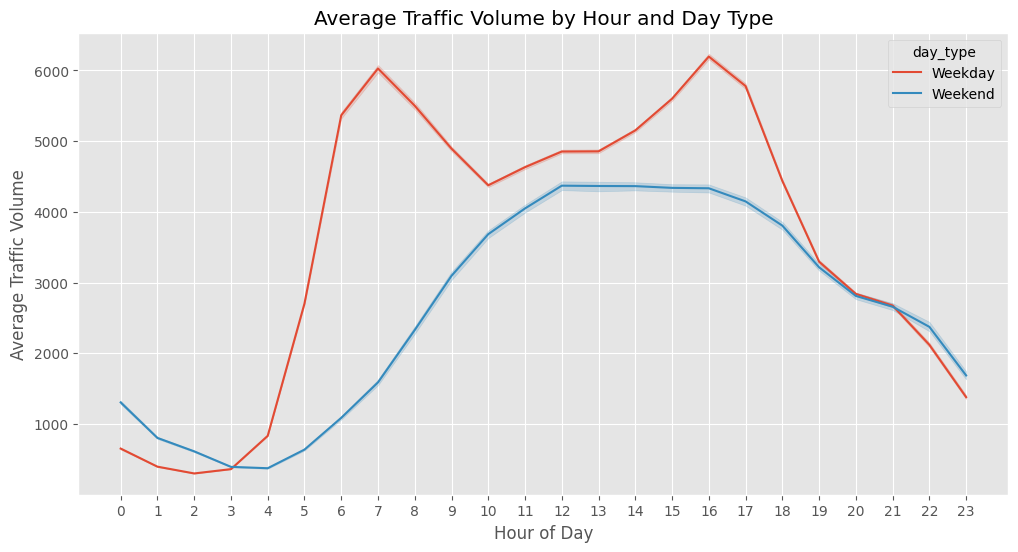

In [60]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x='hour',
    y='traffic_volume',
    hue='day_type',
    estimator='mean'
)

plt.title('Average Traffic Volume by Hour and Day Type')

plt.xlabel('Hour of Day')
plt.ylabel('Average Traffic Volume')

plt.xticks(range(24))

plt.show()

# Bivariate Analysis

## Weather vs Traffic

### 1. Temperature vs Traffic

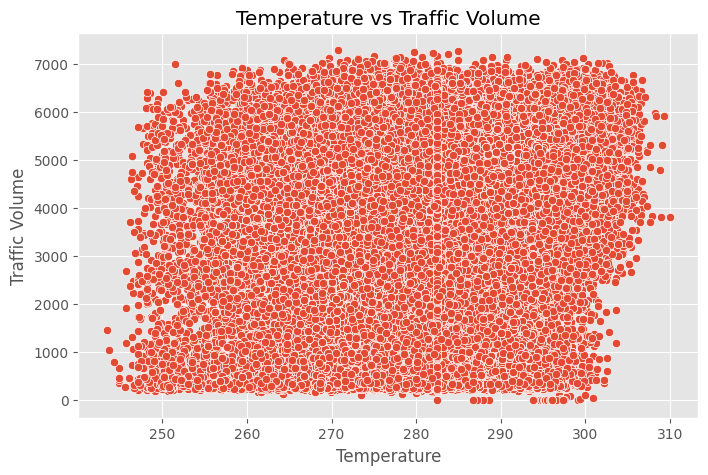

In [61]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='temp',
    y='traffic_volume'
)

plt.title('Temperature vs Traffic Volume')
plt.xlabel('Temperature')
plt.ylabel('Traffic Volume')

plt.show()

### 2. Rain vs Traffic

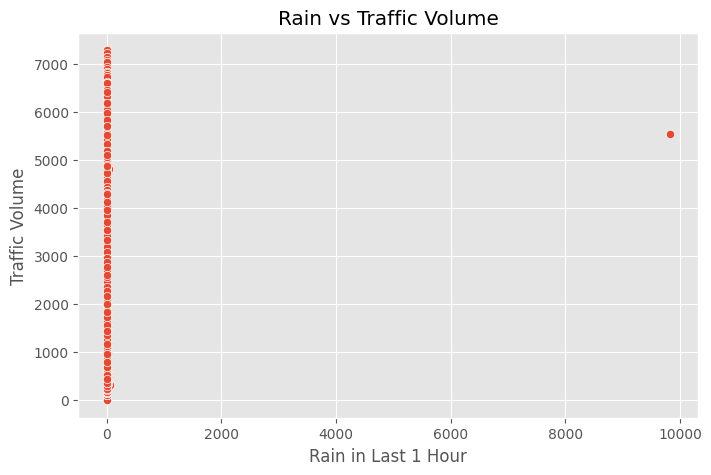

In [62]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='rain_1h',
    y='traffic_volume'
)

plt.title('Rain vs Traffic Volume')
plt.xlabel('Rain in Last 1 Hour')
plt.ylabel('Traffic Volume')

plt.show()

### 3. Snow vs Traffic

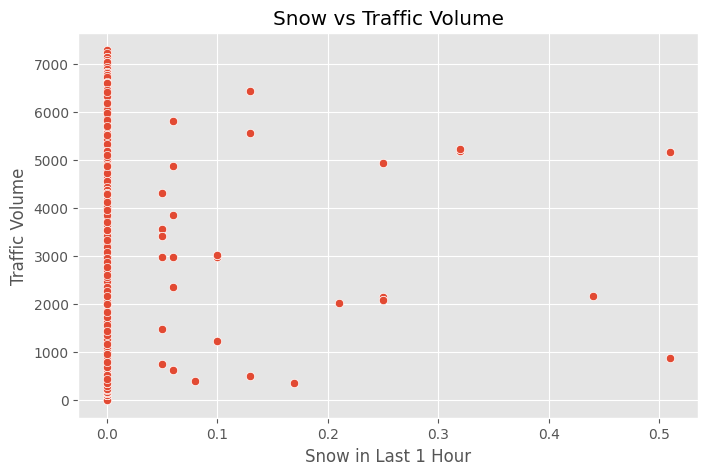

In [63]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='snow_1h',
    y='traffic_volume'
)

plt.title('Snow vs Traffic Volume')
plt.xlabel('Snow in Last 1 Hour')
plt.ylabel('Traffic Volume')

plt.show()

### 4. Wind vs Traffic

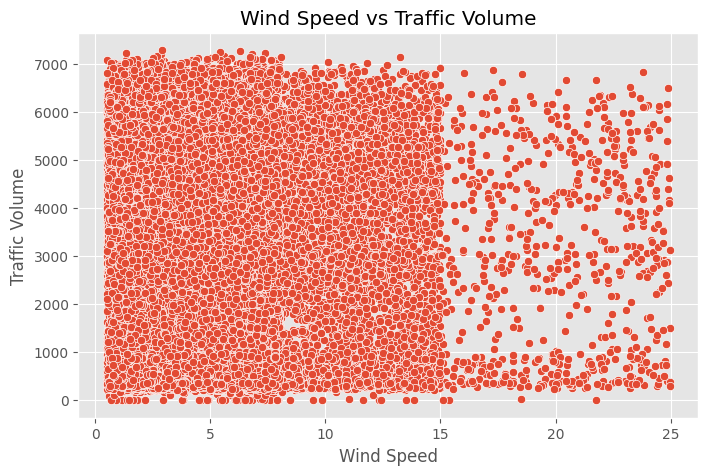

In [64]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='wind_speed_ms',
    y='traffic_volume'
)

plt.title('Wind Speed vs Traffic Volume')
plt.xlabel('Wind Speed')
plt.ylabel('Traffic Volume')

plt.show()

### 5. Fog vs Traffic

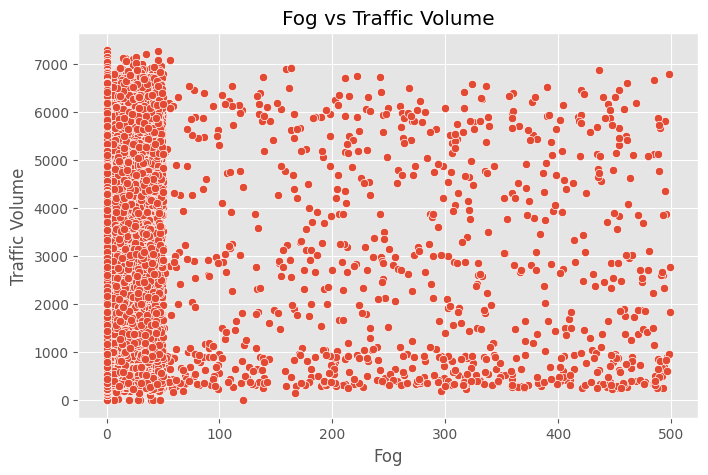

In [65]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='fog_mm',
    y='traffic_volume'
)

plt.title('Fog vs Traffic Volume')
plt.xlabel('Fog')
plt.ylabel('Traffic Volume')

plt.show()

## Categorical Features vs Traffic

### 1. Day Type vs Traffic

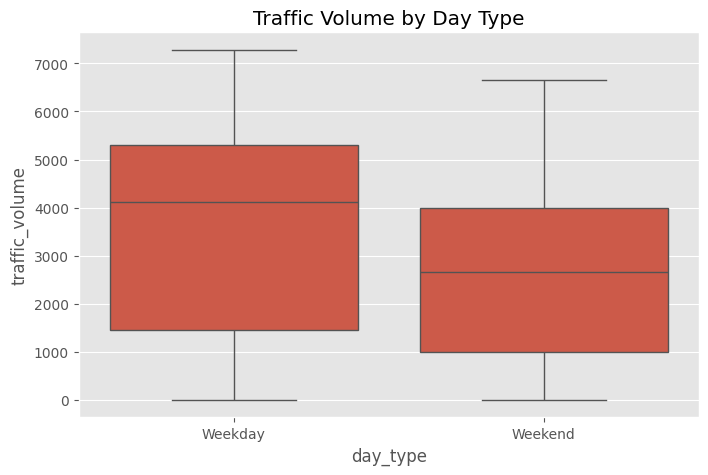

In [66]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='day_type',
    y='traffic_volume'
)

plt.title('Traffic Volume by Day Type')

plt.show()

### 2. Weather Main vs Traffic

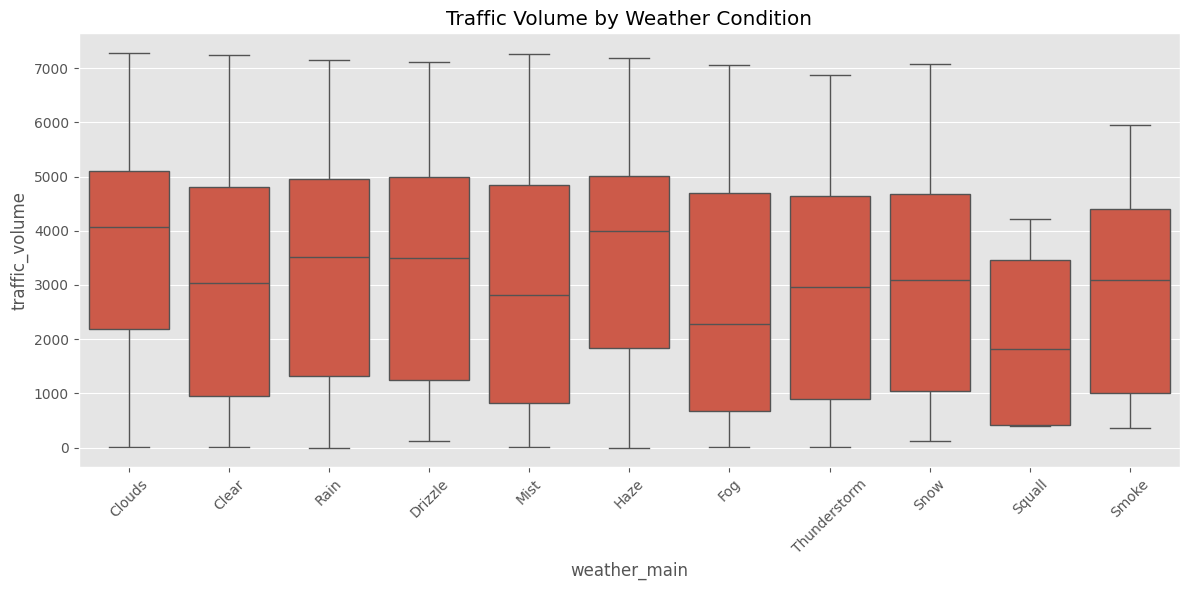

In [67]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='weather_main',
    y='traffic_volume'
)

plt.title('Traffic Volume by Weather Condition')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### 3. Holiday vs Traffic

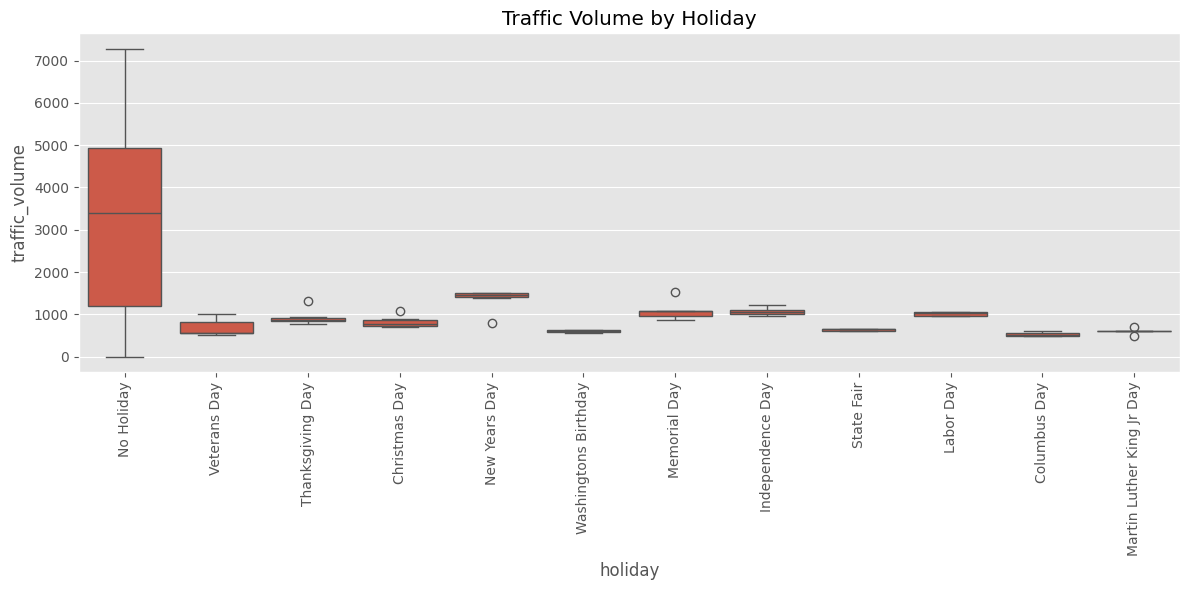

In [68]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='holiday',
    y='traffic_volume'
)

plt.title('Traffic Volume by Holiday')

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

# Multivariate Analysis

### Hour + Weather + Traffic

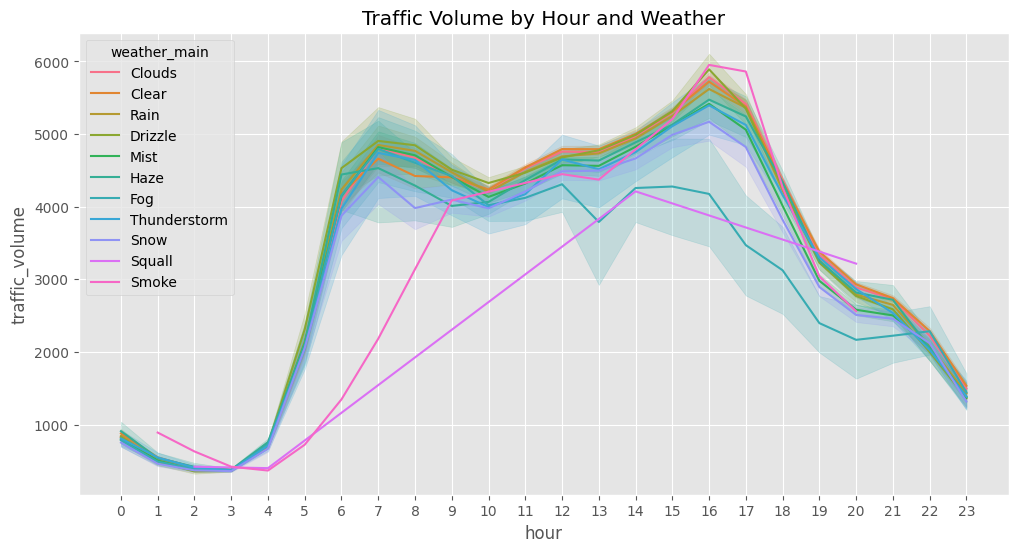

In [70]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x='hour',
    y='traffic_volume',
    hue='weather_main',
    estimator='mean'
)

plt.title('Traffic Volume by Hour and Weather')

plt.xticks(range(24))

plt.show()

###  Traffic Heatmap: Hour × Day of Week

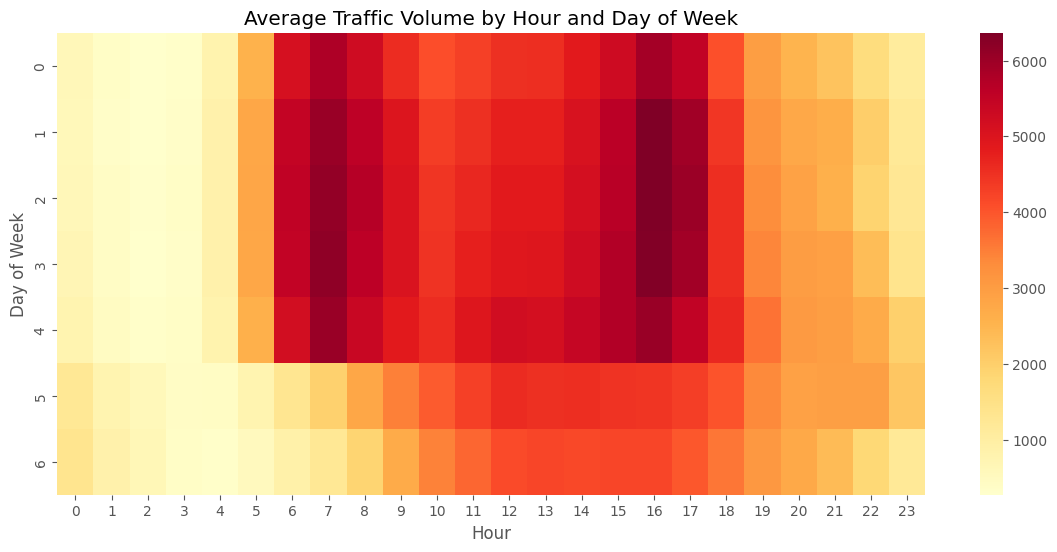

In [71]:
traffic_pivot = df.pivot_table(
    values='traffic_volume',
    index='day_of_week',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    traffic_pivot,
    cmap='YlOrRd'
)

plt.title('Average Traffic Volume by Hour and Day of Week')

plt.xlabel('Hour')
plt.ylabel('Day of Week')

plt.show()

# Correlation Analysis

In [72]:
numeric_cols = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'fog_mm',
    'wind_speed_ms',
    'flood_mm',
    'traffic_volume'
]

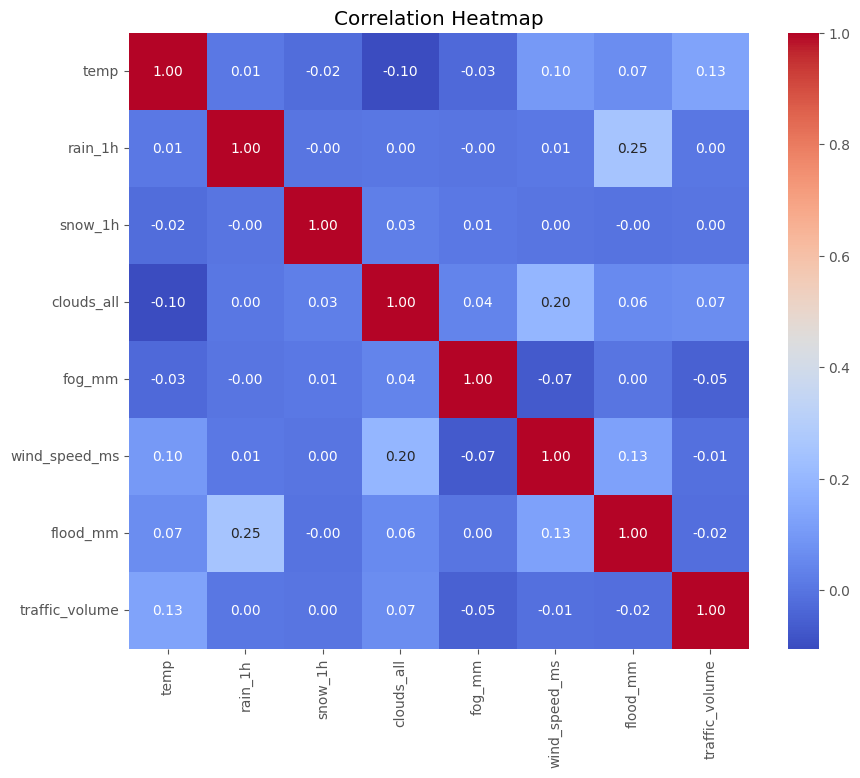

In [73]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [74]:
traffic_corr = (
    df[numeric_cols]
    .corr()['traffic_volume']
    .sort_values(ascending=False)
)

print(traffic_corr)

traffic_volume    1.000000
temp              0.128663
clouds_all        0.065835
rain_1h           0.004869
snow_1h           0.001763
wind_speed_ms    -0.010225
flood_mm         -0.018030
fog_mm           -0.049075
Name: traffic_volume, dtype: float64
